# Patchscope Activation Interpretation Analysis

## What this tests

We give a **source persona** (e.g. conservative) a political question and extract its hidden-state activation — the internal representation it builds while forming an answer. We then inject that activation into a separate **reporter persona's** interpretation pass and see whether it shifts the reporter toward the source's answer.

If personas share internal computation, a same-persona reporter should "read" the injected activation better than an opposite-persona reporter. That would be evidence of **privileged access** — the persona isn't just an output filter, it shapes the representation itself.

## Conditions

| Condition | What happens | Purpose |
|-----------|-------------|---------|
| **real** | Source persona's actual activation is injected into the reporter's prompt | The experimental condition |
| **text_only_baseline** | No activation injected — reporter answers from its own persona + the question text alone | Shows the reporter's default answer without any intervention |
| **shuffled** | A randomly permuted version of the source activation is injected (same magnitude, scrambled structure) | Controls for whether *any* perturbation at that layer shifts logits, regardless of content |

## Key metrics

- **source_gain** = `logit_real(source_answer) − logit_baseline(source_answer)`
  How much the real injection shifts the reporter toward the source's answer, compared to no injection at all.

- **shuffled_gain** = `logit_shuffled(source_answer) − logit_baseline(source_answer)`
  How much a *meaningless* activation perturbation shifts the reporter toward the source's answer. This is the noise floor — if injecting random garbage also boosts the source answer, then source_gain isn't meaningful.

- **net_gain** = `source_gain − shuffled_gain`
  The signal above noise. Positive net_gain means the real activation carries question-specific information that the shuffled control does not.

- **target_drop** = `logit_real(baseline_top) − logit_baseline(baseline_top)`
  How much the injection suppresses the reporter's own default answer.

## Privileged access test

Compare net_gain across reporter types for the same source activation:
- **same-persona** reporter (conservative reads conservative)
- **neutral** reporter
- **opposite-persona** reporter (progressive reads conservative)

If same > neutral > opposite consistently, that's evidence personas have privileged access to their own representations — they aren't interchangeable output filters.

## 1. Setup

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

RESULTS_PATH = '../results/raw/patchscope_llama-3-1-8b_20260322_224126_matrix_cat1and4_.jsonl'

def _extract_model_name(path: str) -> str:
    """Extract model name from patchscope results filename."""
    name = Path(path).stem.lower()
    # Remove prefix/suffix
    for prefix in ['patchscope_', 'patchscope_dual_test_', 'patchscope_test_']:
        if name.startswith(prefix):
            name = name[len(prefix):]
            break
    # Remove timestamp and suffix (e.g. _20260322_224126_matrix_cat1and4_)
    import re
    name = re.sub(r'_\d{8}_\d{6}.*', '', name)
    # Map known model slugs
    model_map = {
        'llama-3-1-8b': 'Llama 3.1 8B Instruct',
        'llama-3-3-70b': 'Llama 3.3 70B Instruct',
        'tinyllama-1-1b--v1-0': 'TinyLlama 1.1B',
        'dolphin-2-9-4-llama3-1-8b': 'Dolphin 2.9.4 Llama 8B',
    }
    return model_map.get(name, name.replace('-', ' ').title())

MODEL = _extract_model_name(RESULTS_PATH)
print(f'Model: {MODEL}')

# Resolve path
_p = Path(RESULTS_PATH)
if not _p.exists():
    for base in [Path.cwd(), Path.cwd().parent]:
        candidate = base / RESULTS_PATH
        if candidate.exists():
            RESULTS_PATH = str(candidate)
            break
assert Path(RESULTS_PATH).exists(), f'Not found: {RESULTS_PATH}'

PERSONA_LABELS = {
    'persona_conservative': 'Conservative',
    'persona_progressive': 'Progressive',
    'neutral_reporter': 'Neutral',
}


REPORTER_ORDER = ['same', 'neutral', 'opposite']


Model: Llama 3.1 8B Instruct


## 2. Load & Prepare Data

In [2]:
records = []
with open(RESULTS_PATH) as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

# Rename evaluator -> reporter to match our terminology
df = df.rename(columns={'evaluator_persona': 'reporter_persona', 'evaluator_system_prompt': 'reporter_system_prompt'})
df['reporter_persona'] = df['reporter_persona'].replace({'neutral_evaluator': 'neutral_reporter'})
print(f'Loaded {len(df)} records')
print(f'Questions: {df["question_id"].nunique()}, Layer pairs: {df.groupby(["source_layer","injection_layer"]).ngroups}')
print(f'Conditions: {df["condition"].value_counts().to_dict()}')

# Join category from task file
TASK_FILE = '../tasks/opposing_personas_politics.json'
_tp = Path(TASK_FILE)
if not _tp.exists():
    _tp = Path.cwd().parent / 'tasks' / 'opposing_personas_politics.json'
if _tp.exists():
    with open(_tp) as f:
        tasks = json.load(f)
    _cat_map = {t['question_id']: t['category_id'] for t in tasks}
    _cat_names = {t['category_id']: t.get('category_name', t['category_id']) for t in tasks}
    df['category'] = df['question_id'].map(_cat_map)
    print(f'Categories: {df["category"].value_counts().to_dict()}')
    print(f'  ' + '\n  '.join(f'{k}: {v}' for k, v in sorted(_cat_names.items()) if k in df['category'].values))
else:
    df['category'] = 'unknown'
    _cat_names = {}
    print('Warning: task file not found, category breakdown unavailable')

CAT_LABELS = {
    'cat_1': 'Cat 1: Policy (disagree)',
    'cat_2': 'Cat 2: Values (disagree)',
    'cat_3': 'Cat 3: Ethical (moderate)',
    'cat_4': 'Cat 4: Factual (control)',
    'cat_5': 'Cat 5: Ambiguous',
}

# Extract logit for source answer
def get_source_answer_logit(row):
    sa = row.get('source_direct_answer')
    logits = row.get('choice_logits')
    if sa and logits and sa in logits:
        return logits[sa]
    return np.nan

df['source_answer_logit'] = df.apply(get_source_answer_logit, axis=1)
df['layer_pair'] = df['source_layer'].astype(str) + '\u2192' + df['injection_layer'].astype(str)

def reporter_relationship(row):
    if row['reporter_persona'] == 'neutral_reporter':
        return 'neutral'
    elif row['reporter_persona'] == row['source_persona']:
        return 'same'
    else:
        return 'opposite'

df['reporter_relation'] = df.apply(reporter_relationship, axis=1)
print(f'Reporter relations: {df["reporter_relation"].value_counts().to_dict()}')

Loaded 10710 records
Questions: 85, Layer pairs: 7
Conditions: {'real': 3570, 'text_only_baseline': 3570, 'shuffled': 3570}
Categories: {'cat_1': 6300, 'cat_4': 4410}
  cat_1: Category 1: Policy Questions (High disagreement expected)
  cat_4: Category 4: Factual Questions (Agreement expected — CONTROL)
Reporter relations: {'same': 3570, 'opposite': 3570, 'neutral': 3570}


## 3. Compute Source Gain Metrics

For each (question, source_persona, reporter, layer_pair), compute:
- **source_gain** = logit_real(source_answer) - logit_baseline(source_answer)
- **shuffled_gain** = logit_shuffled(source_answer) - logit_baseline(source_answer)
- **net_gain** = source_gain - shuffled_gain (question-specific signal above persona noise)

In [3]:
key_cols = ['question_id', 'source_persona', 'reporter_persona', 'source_layer', 'injection_layer']

def build_gain_df(df):
    ae = df[df['template_name'] == 'answer_extraction'].copy()
    # Build a question_id -> category map from the dataframe
    qid_cat = ae.groupby('question_id')['category'].first().to_dict()

    groups = {}
    for _, row in ae.iterrows():
        key = tuple(row[c] for c in key_cols)
        groups.setdefault(key, {})[row['condition']] = row.to_dict()

    gains = []
    for key, conds in groups.items():
        if 'real' not in conds or 'text_only_baseline' not in conds:
            continue
        real = conds['real']
        baseline = conds['text_only_baseline']
        shuffled = conds.get('shuffled')
        src_answer = real.get('source_direct_answer')
        if not src_answer:
            continue
        real_logits = real.get('choice_logits') or {}
        base_logits = baseline.get('choice_logits') or {}
        if not real_logits or not base_logits or src_answer not in real_logits:
            continue

        source_gain = real_logits[src_answer] - base_logits.get(src_answer, 0)
        base_top = max(base_logits, key=base_logits.get)
        target_drop = real_logits.get(base_top, 0) - base_logits[base_top]

        shuf_gain = np.nan
        if shuffled:
            sl = shuffled.get('choice_logits') or {}
            if src_answer in sl:
                shuf_gain = sl[src_answer] - base_logits.get(src_answer, 0)

        eval_p = key[2]
        if eval_p == 'neutral_reporter':
            rel = 'neutral'
        elif eval_p == key[1]:
            rel = 'same'
        else:
            rel = 'opposite'

        gains.append({
            'question_id': key[0], 'source_persona': key[1],
            'reporter_persona': key[2],
            'source_layer': key[3], 'injection_layer': key[4],
            'layer_pair': f'{key[3]}\u2192{key[4]}',
            'category': qid_cat.get(key[0], 'unknown'),
            'source_direct_answer': src_answer,
            'real_predicted': real.get('predicted'),
            'baseline_predicted': baseline.get('predicted'),
            'source_gain': source_gain,
            'target_drop': target_drop,
            'shuffled_gain': shuf_gain,
            'net_gain': source_gain - shuf_gain if not np.isnan(shuf_gain) else np.nan,
            'real_correct': real.get('predicted') == src_answer,
            'baseline_correct': baseline.get('predicted') == src_answer,
            'reporter_relation': rel,
        })
    return pd.DataFrame(gains)

gdf = build_gain_df(df)
gdf['cat_label'] = gdf['category'].map(CAT_LABELS).fillna(gdf['category'])
print(f'Gain records: {len(gdf)}')
print(f'Categories: {gdf["category"].value_counts().to_dict()}')
print(f'\nSource gain summary:')
display(gdf[['source_gain', 'shuffled_gain', 'net_gain']].describe().round(3))

cats_present = sorted(gdf['category'].unique())
cat_labels_present = [CAT_LABELS.get(c, c) for c in cats_present]


Gain records: 3570
Categories: {'cat_1': 2100, 'cat_4': 1470}

Source gain summary:


,source_gain,shuffled_gain,net_gain
count,3570.000,3570.000,3570.000
mean,0.982,0.711,0.271
std,1.037,0.933,0.626
min,-2.109,-2.125,-2.062
25%,0.219,0.088,-0.031
50%,0.797,0.484,0.141
75%,1.561,1.156,0.516
max,6.758,5.641,5.477


## 4. Source Gain by Layer Pair

Which layer pairs best transfer source answer information?

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3073493836.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='layer_pair', y='source_gain', order=lp_order, ax=axes[0], ci=95, color='steelblue')
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3073493836.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='layer_pair', y='shuffled_gain', order=lp_order, ax=axes[1], ci=95, color='salmon')
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3073493836.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='layer_pair', y='net_gain', order=lp_order, ax=axes[2], ci=95, color='seagreen')


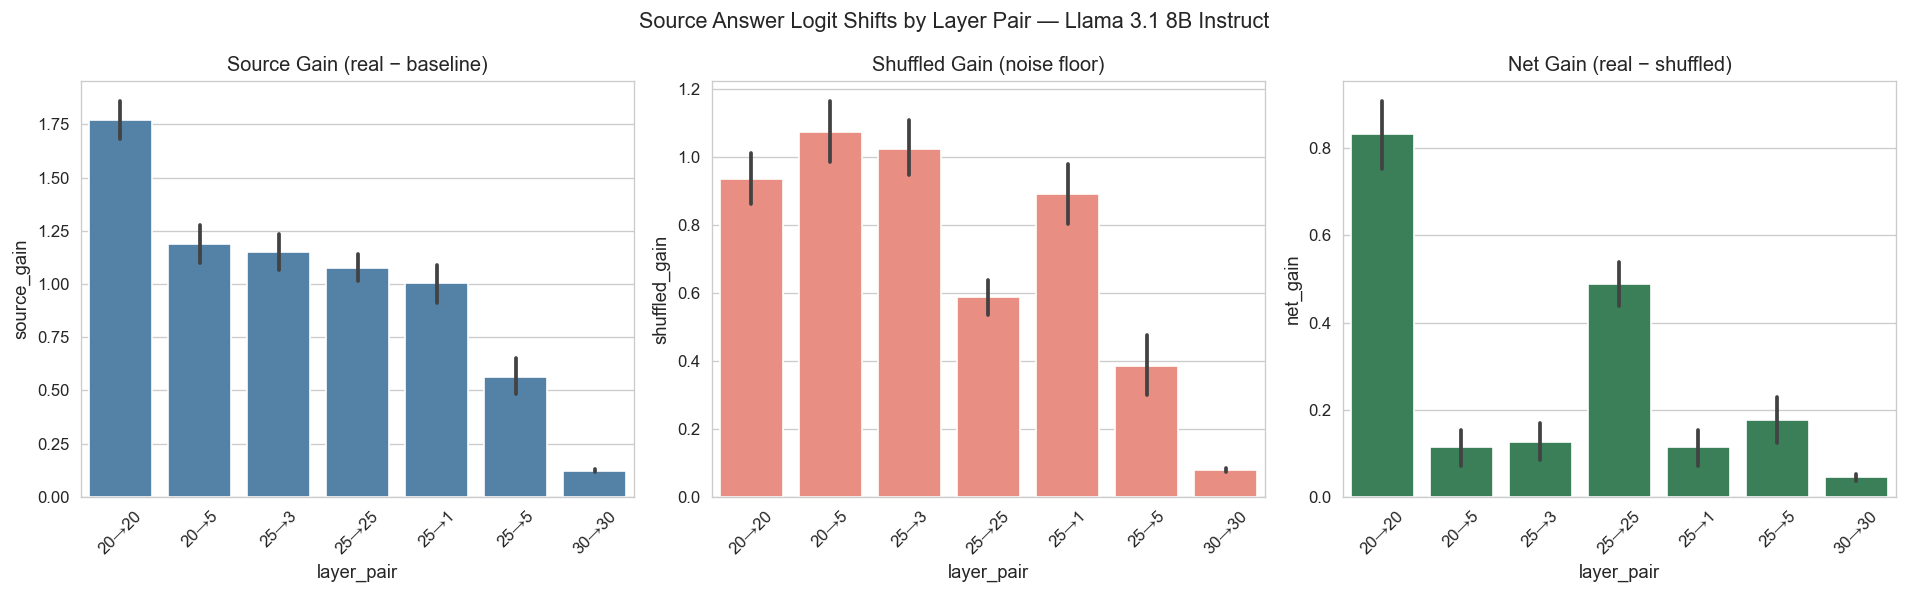

,source_gain_mean,source_gain_std,shuffled_gain_mean,net_gain_mean,pct_positive_gain,real_accuracy,baseline_accuracy,n
layer_pair,,,,,,,,
20→20,1.768,1.058,0.935,0.833,0.998,0.606,0.488,510
25→25,1.077,0.708,0.588,0.489,0.998,0.545,0.488,510
25→5,0.562,1.024,0.387,0.176,0.724,0.545,0.488,510
25→3,1.150,0.978,1.024,0.125,0.898,0.561,0.488,510
20→5,1.188,1.106,1.074,0.114,0.914,0.565,0.488,510
25→1,1.004,1.035,0.890,0.114,0.839,0.553,0.488,510
30→30,0.124,0.101,0.079,0.045,0.918,0.488,0.488,510


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
lp_order = gdf.groupby('layer_pair')['source_gain'].mean().sort_values(ascending=False).index.tolist()

sns.barplot(data=gdf, x='layer_pair', y='source_gain', order=lp_order, ax=axes[0], ci=95, color='steelblue')
axes[0].set_title('Source Gain (real \u2212 baseline)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=gdf, x='layer_pair', y='shuffled_gain', order=lp_order, ax=axes[1], ci=95, color='salmon')
axes[1].set_title('Shuffled Gain (noise floor)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=gdf, x='layer_pair', y='net_gain', order=lp_order, ax=axes[2], ci=95, color='seagreen')
axes[2].set_title('Net Gain (real \u2212 shuffled)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].tick_params(axis='x', rotation=45)

fig.suptitle(f'Source Answer Logit Shifts by Layer Pair \u2014 {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

lp_stats = gdf.groupby('layer_pair').agg(
    source_gain_mean=('source_gain', 'mean'),
    source_gain_std=('source_gain', 'std'),
    shuffled_gain_mean=('shuffled_gain', 'mean'),
    net_gain_mean=('net_gain', 'mean'),
    pct_positive_gain=('source_gain', lambda x: (x > 0).mean()),
    real_accuracy=('real_correct', 'mean'),
    baseline_accuracy=('baseline_correct', 'mean'),
    n=('source_gain', 'count'),
).round(3).sort_values('net_gain_mean', ascending=False)
display(lp_stats)

## 5. Privileged Access: Cross-Reporter Comparison

The key test: does the **same-persona** reporter show larger source_gain than **neutral** or **opposite**?

If personas have privileged access: same > neutral > opposite

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3333808471.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='reporter_relation', y='source_gain', order=reporter_order, ax=axes[0], ci=95, palette='Set2')
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3333808471.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gdf, x='reporter_relation', y='source_gain', order=reporter_order, ax=axes[0], ci=95, palette='Set2')
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3333808471.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='reporter_relation', y='shuffled_gain', order=reporter_order, ax=axes[1], ci=95, palette='Set2')
/var/fol

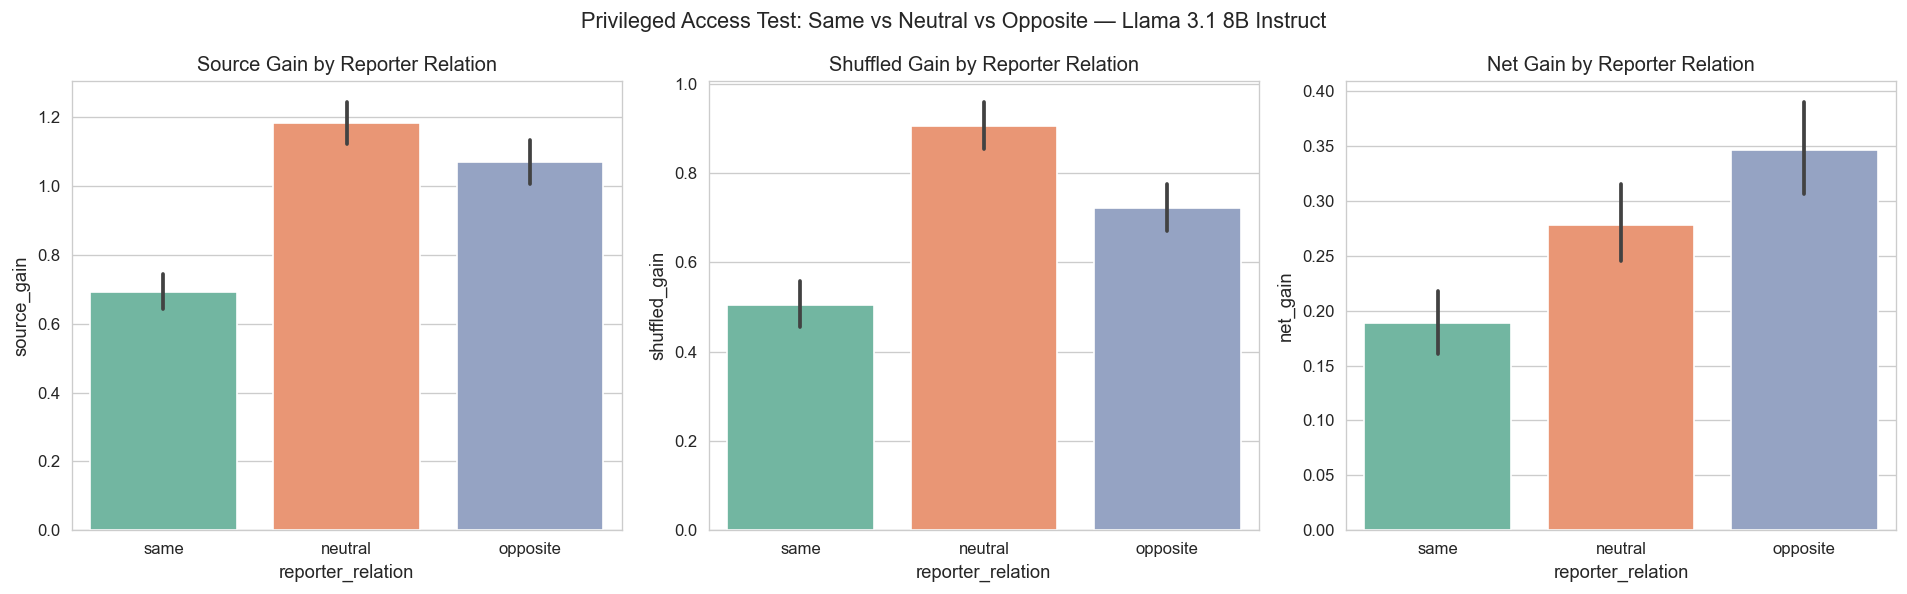

,source_gain_mean,shuffled_gain_mean,net_gain_mean,real_accuracy,baseline_accuracy,n
reporter_relation,,,,,,
same,0.6926,0.5041,0.1885,0.7697,0.7353,1190
neutral,1.1841,0.9061,0.2780,0.4798,0.3765,1190
opposite,1.0691,0.7231,0.3460,0.4059,0.3529,1190


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
reporter_order = REPORTER_ORDER  # defined in setup

sns.barplot(data=gdf, x='reporter_relation', y='source_gain', order=reporter_order, ax=axes[0], ci=95, palette='Set2')
axes[0].set_title('Source Gain by Reporter Relation')
axes[0].axhline(0, color='black', linewidth=0.5)

sns.barplot(data=gdf, x='reporter_relation', y='shuffled_gain', order=reporter_order, ax=axes[1], ci=95, palette='Set2')
axes[1].set_title('Shuffled Gain by Reporter Relation')
axes[1].axhline(0, color='black', linewidth=0.5)

sns.barplot(data=gdf, x='reporter_relation', y='net_gain', order=reporter_order, ax=axes[2], ci=95, palette='Set2')
axes[2].set_title('Net Gain by Reporter Relation')
axes[2].axhline(0, color='black', linewidth=0.5)

fig.suptitle(f'Privileged Access Test: Same vs Neutral vs Opposite \u2014 {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

reporter_stats = gdf.groupby('reporter_relation').agg(
    source_gain_mean=('source_gain', 'mean'),
    shuffled_gain_mean=('shuffled_gain', 'mean'),
    net_gain_mean=('net_gain', 'mean'),
    real_accuracy=('real_correct', 'mean'),
    baseline_accuracy=('baseline_correct', 'mean'),
    n=('source_gain', 'count'),
).round(4).loc[reporter_order]
display(reporter_stats)

## 6. Cross-Reporter \u00d7 Layer Pair Heatmap

Does the reporter relationship effect vary by layer pair?

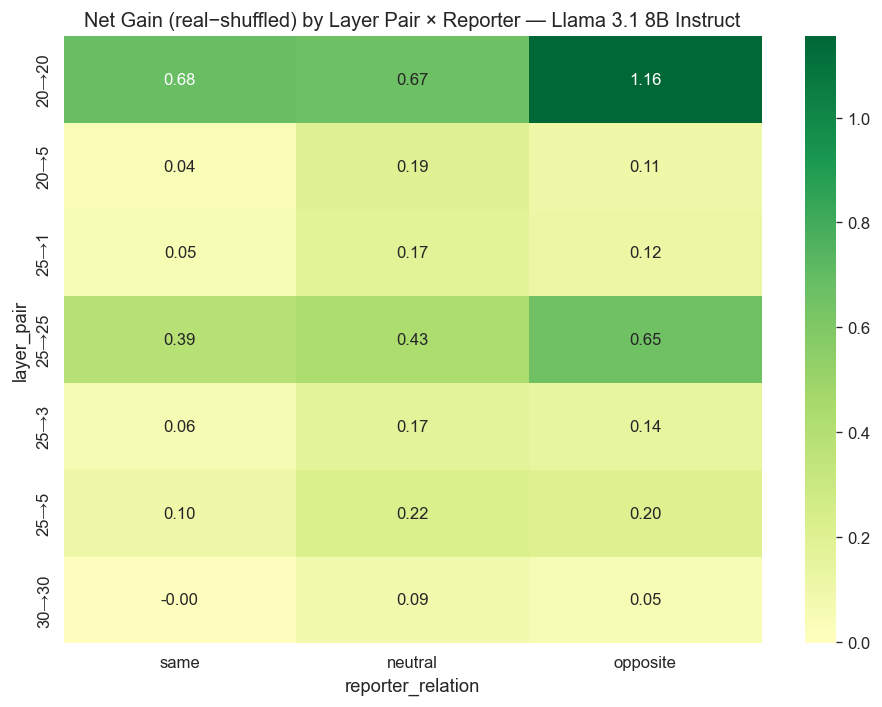

In [6]:
pivot = gdf.pivot_table(values='net_gain', index='layer_pair', columns='reporter_relation', aggfunc='mean')[reporter_order]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title(f'Net Gain (real\u2212shuffled) by Layer Pair \u00d7 Reporter \u2014 {MODEL}')
plt.tight_layout()
plt.show()

## 7. Reporter Persona Dominance

How often does the reporter's baseline prior override the injected source activation?

Source and baseline agree: 48.8%
Source and baseline disagree: 51.2%

When they disagree, injection flips to source answer: 15.4%

Flip rate by reporter relation (disagreement trials):
        same: 23.2% (315 trials)
     neutral: 16.7% (742 trials)
    opposite: 11.0% (770 trials)

Mean source_gain on agree vs disagree trials:
  Agree:    0.576
  Disagree: 1.369


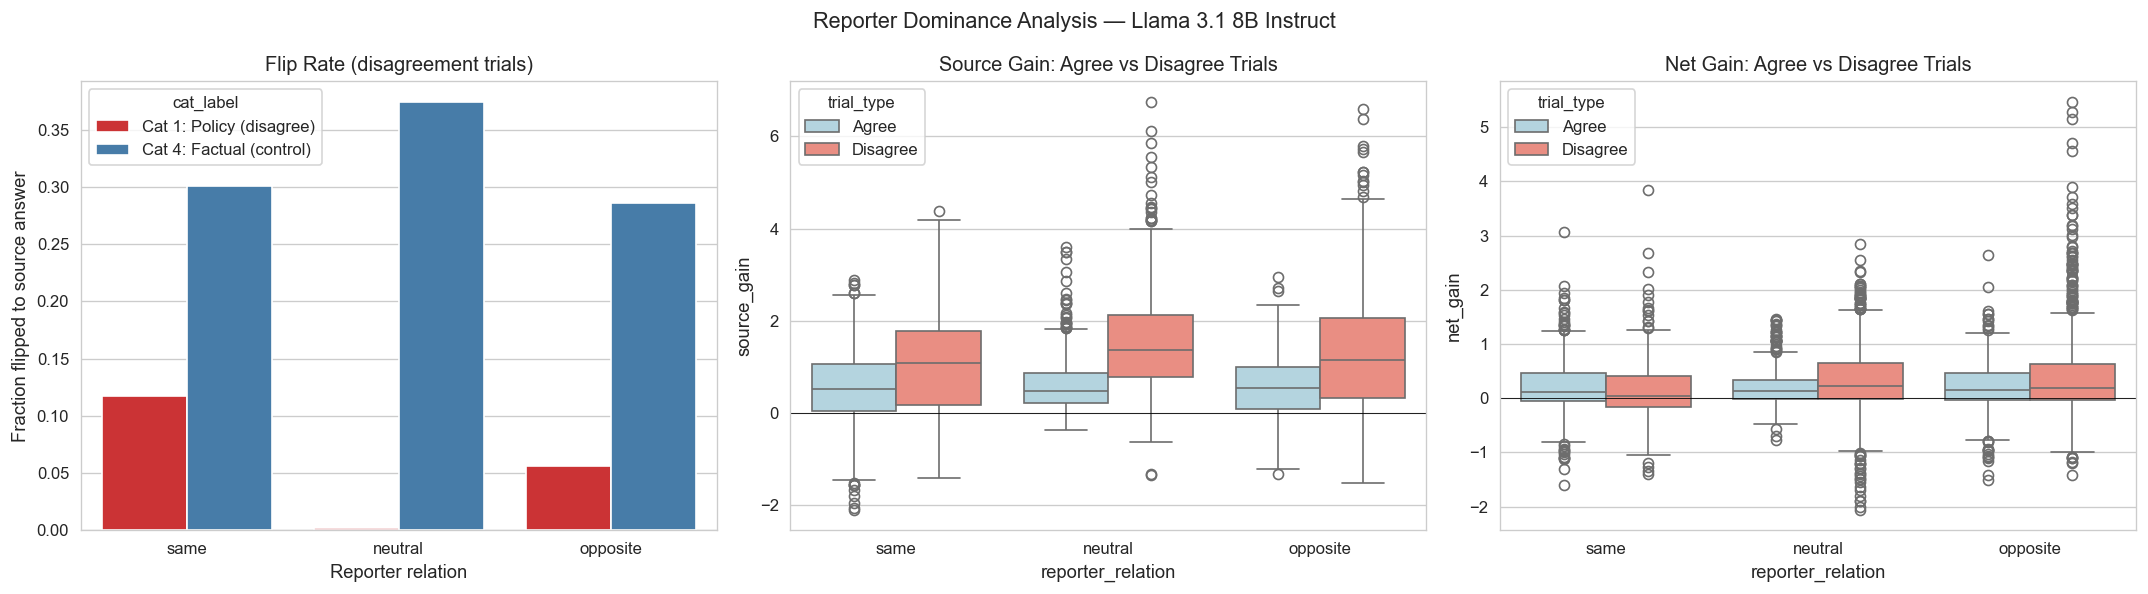

In [7]:
gdf['source_baseline_agree'] = gdf['source_direct_answer'] == gdf['baseline_predicted']
disagree = gdf[~gdf['source_baseline_agree']].copy()
disagree['flipped_to_source'] = disagree['real_predicted'] == disagree['source_direct_answer']

print(f'Source and baseline agree: {gdf["source_baseline_agree"].mean():.1%}')
print(f'Source and baseline disagree: {(~gdf["source_baseline_agree"]).mean():.1%}')
print(f'\nWhen they disagree, injection flips to source answer: {disagree["flipped_to_source"].mean():.1%}')

reporter_order = REPORTER_ORDER  # defined in setup
print('\nFlip rate by reporter relation (disagreement trials):')
for rel in reporter_order:
    sub = disagree[disagree['reporter_relation'] == rel]
    if len(sub) > 0:
        print(f'  {rel:>10s}: {sub["flipped_to_source"].mean():.1%} ({len(sub)} trials)')

print(f'\nMean source_gain on agree vs disagree trials:')
print(f'  Agree:    {gdf[gdf["source_baseline_agree"]]["source_gain"].mean():.3f}')
print(f'  Disagree: {disagree["source_gain"].mean():.3f}')

# --- Visuals ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Flip rate by reporter × category
flip_data = disagree.copy()
flip_data['cat_label'] = flip_data['category'].map(CAT_LABELS).fillna(flip_data['category'])
flip_rates = flip_data.groupby(['reporter_relation', 'cat_label'])['flipped_to_source'].mean().reset_index()
sns.barplot(data=flip_rates, x='reporter_relation', y='flipped_to_source', hue='cat_label',
            order=reporter_order, ax=axes[0], palette='Set1')
axes[0].set_title('Flip Rate (disagreement trials)')
axes[0].set_ylabel('Fraction flipped to source answer')
axes[0].set_xlabel('Reporter relation')
axes[0].axhline(0, color='black', linewidth=0.5)

# 2. Source gain distribution: agree vs disagree
agree_data = gdf.copy()
agree_data['trial_type'] = np.where(agree_data['source_baseline_agree'], 'Agree', 'Disagree')
sns.boxplot(data=agree_data, x='reporter_relation', y='source_gain', hue='trial_type',
            order=reporter_order, ax=axes[1], palette={'Agree': 'lightblue', 'Disagree': 'salmon'})
axes[1].set_title('Source Gain: Agree vs Disagree Trials')
axes[1].axhline(0, color='black', linewidth=0.5)

# 3. Net gain distribution: agree vs disagree
sns.boxplot(data=agree_data, x='reporter_relation', y='net_gain', hue='trial_type',
            order=reporter_order, ax=axes[2], palette={'Agree': 'lightblue', 'Disagree': 'salmon'})
axes[2].set_title('Net Gain: Agree vs Disagree Trials')
axes[2].axhline(0, color='black', linewidth=0.5)

fig.suptitle(f'Reporter Dominance Analysis — {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
from scipy import stats

# --- Chi-squared test: flip rate same vs opposite ---
# disagree is computed in the cell above (cell 14)
same_d = disagree[disagree['reporter_relation'] == 'same']
opp_d = disagree[disagree['reporter_relation'] == 'opposite']
neut_d = disagree[disagree['reporter_relation'] == 'neutral']

# 2x2 contingency table: same vs opposite
table_so = np.array([
    [same_d['flipped_to_source'].sum(), len(same_d) - same_d['flipped_to_source'].sum()],
    [opp_d['flipped_to_source'].sum(), len(opp_d) - opp_d['flipped_to_source'].sum()],
])
chi2_so, p_so, _, _ = stats.chi2_contingency(table_so)

# 2x2: same vs neutral
table_sn = np.array([
    [same_d['flipped_to_source'].sum(), len(same_d) - same_d['flipped_to_source'].sum()],
    [neut_d['flipped_to_source'].sum(), len(neut_d) - neut_d['flipped_to_source'].sum()],
])
chi2_sn, p_sn, _, _ = stats.chi2_contingency(table_sn)

# 3-way chi-squared
table_3 = np.array([
    [same_d['flipped_to_source'].sum(), len(same_d) - same_d['flipped_to_source'].sum()],
    [neut_d['flipped_to_source'].sum(), len(neut_d) - neut_d['flipped_to_source'].sum()],
    [opp_d['flipped_to_source'].sum(), len(opp_d) - opp_d['flipped_to_source'].sum()],
])
chi2_3, p_3, _, _ = stats.chi2_contingency(table_3)

def _sig(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

print('Chi-squared tests on flip rate (disagreement trials only)')
print('=' * 60)
print(f'Same ({same_d["flipped_to_source"].mean():.1%}, n={len(same_d)}) vs '
      f'Opposite ({opp_d["flipped_to_source"].mean():.1%}, n={len(opp_d)}):')
print(f'  \u03c7\u00b2={chi2_so:.2f}, p={p_so:.4f} {_sig(p_so)}')
print(f'\nSame vs Neutral ({neut_d["flipped_to_source"].mean():.1%}, n={len(neut_d)}):')
print(f'  \u03c7\u00b2={chi2_sn:.2f}, p={p_sn:.4f} {_sig(p_sn)}')
print(f'\n3-way (same vs neutral vs opposite):')
print(f'  \u03c7\u00b2={chi2_3:.2f}, p={p_3:.4f} {_sig(p_3)}')

# --- Bootstrap CI on flip rate difference (same - opposite) ---
n_boot = 10000
rng = np.random.default_rng(42)
same_flips = same_d['flipped_to_source'].values.astype(float)
opp_flips = opp_d['flipped_to_source'].values.astype(float)

boot_diffs = np.array([
    rng.choice(same_flips, size=len(same_flips), replace=True).mean()
    - rng.choice(opp_flips, size=len(opp_flips), replace=True).mean()
    for _ in range(n_boot)
])
ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
obs_diff = same_flips.mean() - opp_flips.mean()

print(f'\nBootstrap 95% CI for flip rate difference (same \u2212 opposite):')
print(f'  Observed: {obs_diff:.1%}')
print(f'  95% CI:   [{ci_lo:.1%}, {ci_hi:.1%}]')
print(f'  {"Significant (CI excludes 0)" if ci_lo > 0 else "Not significant (CI includes 0)"}')

# --- Logistic regression controlling for source_gain ---
# disagree is a subset of gdf, so it already has source_gain
disagree_lr = disagree.copy()

print(f'\n{"=" * 60}')
print('Logistic regression: does reporter_relation predict flipping')
print('after controlling for source_gain (logit shift)?')
print('=' * 60)

try:
    from sklearn.linear_model import LogisticRegression

    X_data = pd.DataFrame({
        'eval_same': (disagree_lr['reporter_relation'] == 'same').astype(int),
        'eval_opposite': (disagree_lr['reporter_relation'] == 'opposite').astype(int),
        'source_gain': disagree_lr['source_gain'],
    })
    y = disagree_lr['flipped_to_source'].astype(int).values

    mask = X_data.notna().all(axis=1) & ~np.isnan(y)
    X = X_data.loc[mask].values
    y = y[mask.values]

    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X, y)

    print(f'\n  Features: eval_same, eval_opposite, source_gain (baseline=neutral)')
    for name, coef in zip(['eval_same', 'eval_opposite', 'source_gain'], lr.coef_[0]):
        print(f'    {name:>15s}: coef={coef:+.3f}')
    print(f'    {"intercept":>15s}: {lr.intercept_[0]:+.3f}')

    same_coef = lr.coef_[0][0]
    opp_coef = lr.coef_[0][1]
    if same_coef > 0 and opp_coef < 0:
        print(f'\n  Same-persona has higher flip rate even after controlling for source_gain.')
        print(f'  Consistent with privileged access (but not proof \u2014 could be other confounds).')
    elif same_coef > 0:
        print(f'\n  Same-persona has higher flip rate after control, but opposite is not lower than neutral.')
    else:
        print(f'\n  After controlling for source_gain, same-persona advantage disappears.')
        print(f'  Flip rate difference likely explained by baseline proximity, not privileged access.')

except ImportError:
    print('  sklearn not available \u2014 skipping logistic regression.')


Chi-squared tests on flip rate (disagreement trials only)
Same (23.2%, n=315) vs Opposite (11.0%, n=770):
  χ²=25.50, p=0.0000 ***

Same vs Neutral (16.7%, n=742):
  χ²=5.67, p=0.0172 *

3-way (same vs neutral vs opposite):
  χ²=26.78, p=0.0000 ***

Bootstrap 95% CI for flip rate difference (same − opposite):
  Observed: 12.1%
  95% CI:   [7.0%, 17.4%]
  Significant (CI excludes 0)

Logistic regression: does reporter_relation predict flipping
after controlling for source_gain (logit shift)?

  Features: eval_same, eval_opposite, source_gain (baseline=neutral)
          eval_same: coef=+0.561
      eval_opposite: coef=-0.439
        source_gain: coef=+0.384
          intercept: -2.242

  Same-persona has higher flip rate even after controlling for source_gain.
  Consistent with privileged access (but not proof — could be other confounds).


### Statistical Tests: Flip Rate Differences

Is the same-persona flip rate significantly higher than opposite-persona?

**Caveat:** The same-persona reporter was already closer to the source answer at baseline, so it has a shorter distance to flip. To control for this, we also test whether the flip rate difference survives after controlling for baseline source-answer logit (i.e., how "close" the reporter already was).

## 8. Source Gain Distribution

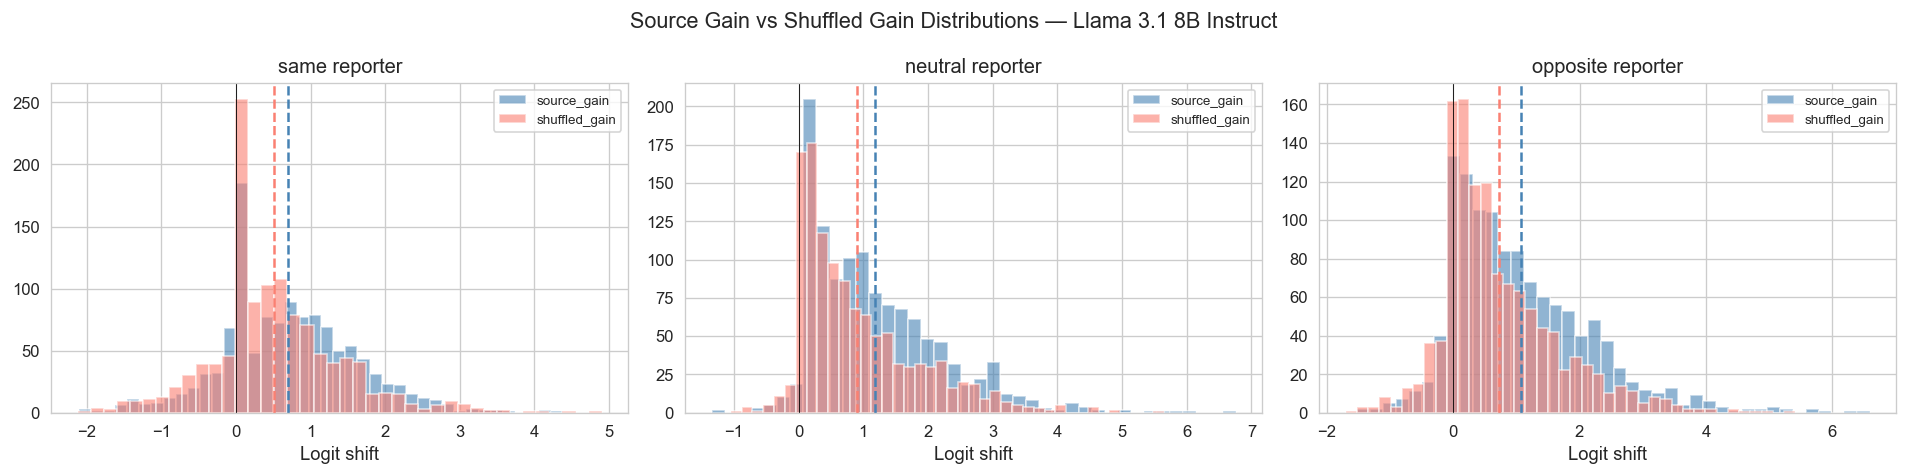

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, rel in zip(axes, reporter_order):
    sub = gdf[gdf['reporter_relation'] == rel]
    ax.hist(sub['source_gain'].dropna(), bins=40, alpha=0.6, color='steelblue', label='source_gain')
    ax.hist(sub['shuffled_gain'].dropna(), bins=40, alpha=0.6, color='salmon', label='shuffled_gain')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.axvline(sub['source_gain'].mean(), color='steelblue', linestyle='--', linewidth=1.5)
    ax.axvline(sub['shuffled_gain'].mean(), color='salmon', linestyle='--', linewidth=1.5)
    ax.set_title(f'{rel} reporter')
    ax.set_xlabel('Logit shift')
    ax.legend(fontsize=8)

fig.suptitle(f'Source Gain vs Shuffled Gain Distributions \u2014 {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Same-Layer vs Cross-Layer Pairs

The toy Bezos test suggested late\u2192early pairs are best for semantic decoding.
For MCQ answer extraction with reporter prompts, does this still hold?

source_gain_mean  net_gain_mean  real_accuracy  \
pair_type   reporter_relation                                                   
cross-layer neutral                      1.4655         0.1903         0.4809   
            opposite                     0.8992         0.1420         0.4074   
            same                         0.5639         0.0648         0.7794   
same-layer  neutral                      0.8091         0.3950         0.4784   
            opposite                     1.2955         0.6179         0.4039   
            same                         0.8643         0.3533         0.7569   

                                 n  
pair_type   reporter_relation       
cross-layer neutral            680  
            opposite           680  
            same               680  
same-layer  neutral            510  
            opposite           510  
            same               510

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/1987321946.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='pair_type', y=metric, hue='reporter_relation',
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/1987321946.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='pair_type', y=metric, hue='reporter_relation',


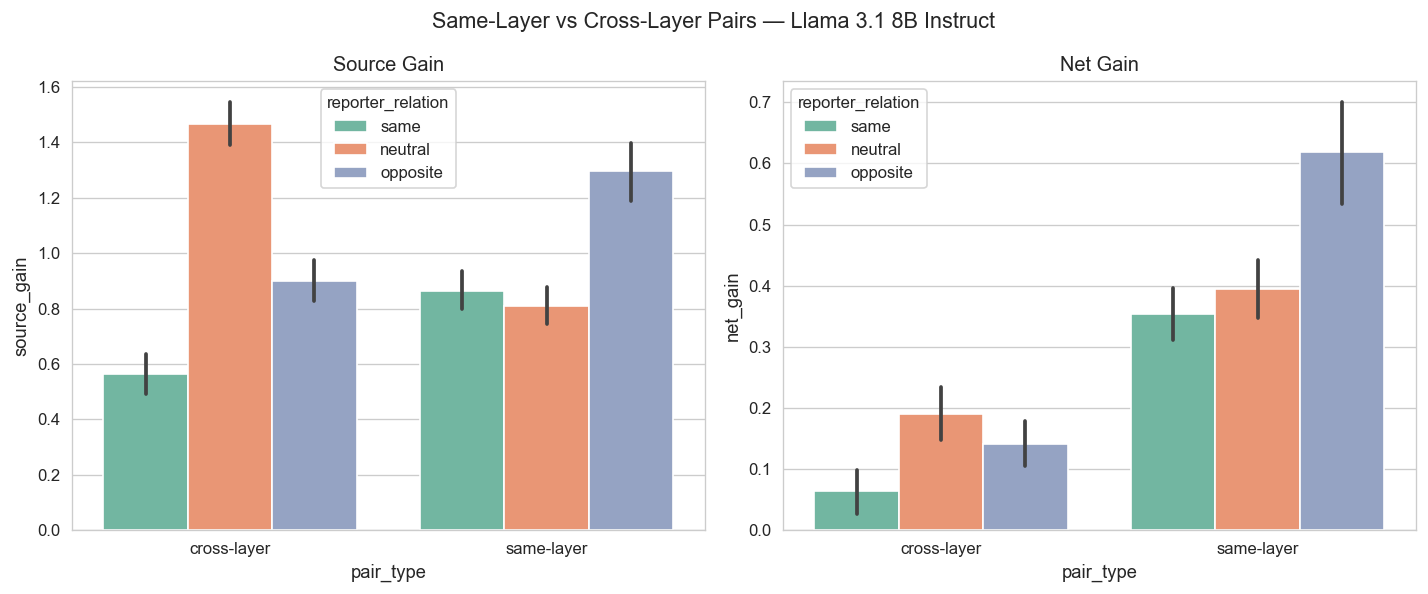

In [10]:
gdf['pair_type'] = np.where(gdf['source_layer'] == gdf['injection_layer'], 'same-layer', 'cross-layer')

pair_comp = gdf.groupby(['pair_type', 'reporter_relation']).agg(
    source_gain_mean=('source_gain', 'mean'),
    net_gain_mean=('net_gain', 'mean'),
    real_accuracy=('real_correct', 'mean'),
    n=('source_gain', 'count'),
).round(4)
display(pair_comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, title in zip(axes, ['source_gain', 'net_gain'], ['Source Gain', 'Net Gain']):
    sns.barplot(data=gdf, x='pair_type', y=metric, hue='reporter_relation',
                hue_order=reporter_order, ax=ax, ci=95, palette='Set2')
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.5)

fig.suptitle(f'Same-Layer vs Cross-Layer Pairs \u2014 {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Per-Question Scatter: Source Gain vs Shuffled Gain

Points above the diagonal = question-specific signal beyond persona noise.

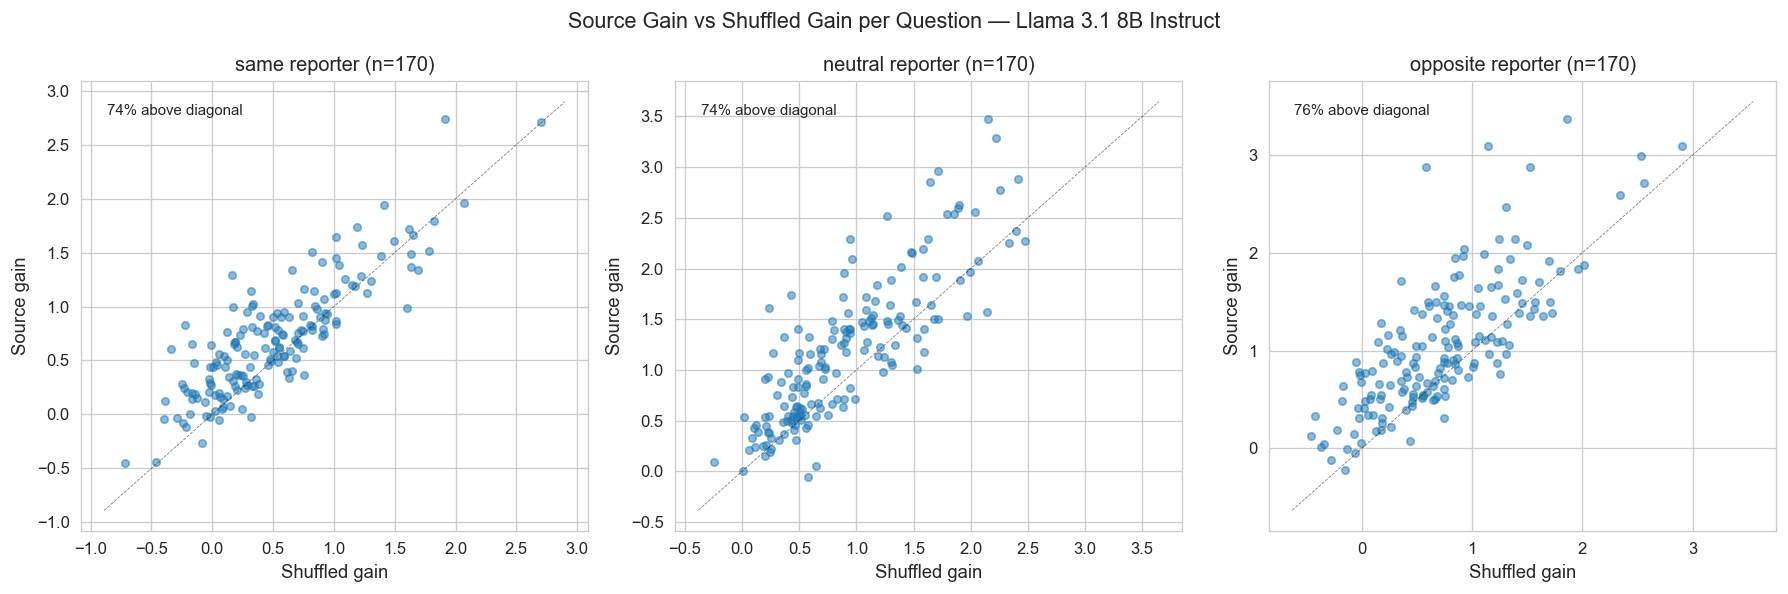

In [11]:
q_avg = gdf.groupby(['question_id', 'source_persona', 'reporter_relation']).agg(
    source_gain=('source_gain', 'mean'),
    shuffled_gain=('shuffled_gain', 'mean'),
    net_gain=('net_gain', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, rel in zip(axes, reporter_order):
    sub = q_avg[q_avg['reporter_relation'] == rel]
    ax.scatter(sub['shuffled_gain'], sub['source_gain'], alpha=0.5, s=20)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5)
    ax.set_xlabel('Shuffled gain')
    ax.set_ylabel('Source gain')
    ax.set_title(f'{rel} reporter (n={len(sub)})')
    above = (sub['source_gain'] > sub['shuffled_gain']).mean()
    ax.text(0.05, 0.95, f'{above:.0%} above diagonal', transform=ax.transAxes, va='top', fontsize=9)

fig.suptitle(f'Source Gain vs Shuffled Gain per Question \u2014 {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Full Logit Shift by Option Type

Average logit shift for source-answer options vs non-source options.

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3830300786.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=osdf, x='reporter_relation', y='logit_shift', hue='is_source_answer',


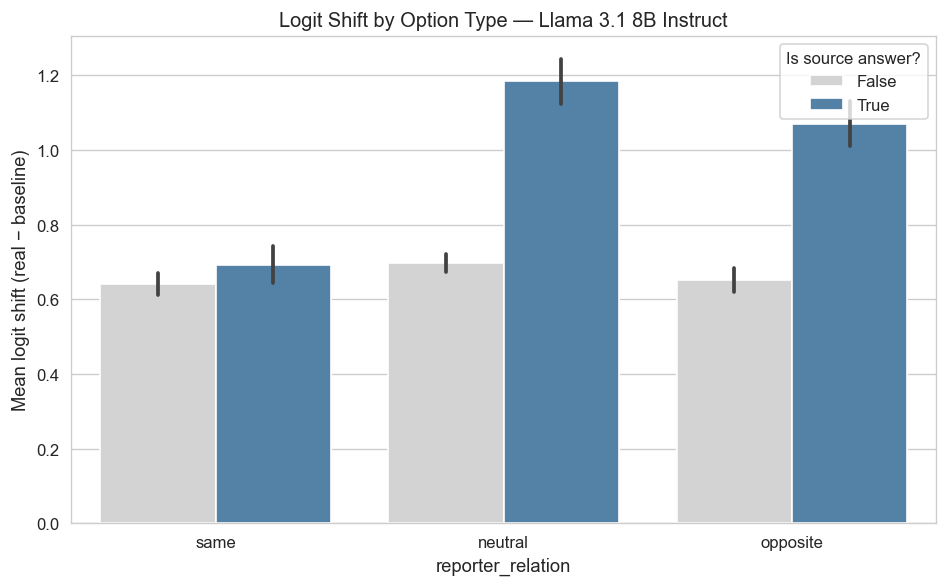

In [12]:
ae = df[df['template_name'] == 'answer_extraction'].copy()
groups = {}
for _, row in ae.iterrows():
    key = tuple(row[c] for c in key_cols)
    groups.setdefault(key, {})[row['condition']] = row.to_dict()

option_shifts = []
for key, conds in groups.items():
    if 'real' not in conds or 'text_only_baseline' not in conds:
        continue
    real_l = conds['real'].get('choice_logits') or {}
    base_l = conds['text_only_baseline'].get('choice_logits') or {}
    src_a = conds['real'].get('source_direct_answer')
    if not real_l or not base_l or not src_a:
        continue
    ep = key[2]
    rel = 'neutral' if ep == 'neutral_reporter' else ('same' if ep == key[1] else 'opposite')
    for opt in ['A', 'B', 'C', 'D']:
        if opt in real_l and opt in base_l:
            option_shifts.append({'option': opt, 'is_source_answer': opt == src_a,
                                  'reporter_relation': rel, 'logit_shift': real_l[opt] - base_l[opt]})

osdf = pd.DataFrame(option_shifts)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=osdf, x='reporter_relation', y='logit_shift', hue='is_source_answer',
            order=reporter_order, ax=ax, ci=95, palette={True: 'steelblue', False: 'lightgray'})
ax.set_title(f'Logit Shift by Option Type \u2014 {MODEL}')
ax.set_ylabel('Mean logit shift (real \u2212 baseline)')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(title='Is source answer?', loc='upper right')
plt.tight_layout()
plt.show()

## 12. Key Findings Summary

In [13]:
print('=' * 60)
print(f'PATCHSCOPE RESULTS SUMMARY — {MODEL}')
print('=' * 60)
print(f'\nDataset: {gdf["question_id"].nunique()} questions, {len(gdf)} gain measurements')
print(f'Layer pairs: {sorted(gdf["layer_pair"].unique())}')

print(f'\n--- Overall ---')
print(f'Mean source_gain:   {gdf["source_gain"].mean():+.3f}')
print(f'Mean shuffled_gain: {gdf["shuffled_gain"].mean():+.3f}')
print(f'Mean net_gain:      {gdf["net_gain"].mean():+.3f}')
print(f'% positive source_gain: {(gdf["source_gain"] > 0).mean():.1%}')
print(f'% positive net_gain:    {(gdf["net_gain"] > 0).mean():.1%}')

print(f'\n--- Privileged Access Test (overall) ---')
for rel in reporter_order:
    sub = gdf[gdf['reporter_relation'] == rel]
    print(f'  {rel:>10s}: source_gain={sub["source_gain"].mean():+.3f}  '
          f'net_gain={sub["net_gain"].mean():+.3f}  '
          f'accuracy(real)={sub["real_correct"].mean():.1%}  '
          f'accuracy(baseline)={sub["baseline_correct"].mean():.1%}')

print(f'\n--- Privileged Access by Category ---')
for cat in sorted(gdf['category'].unique()):
    cat_sub = gdf[gdf['category'] == cat]
    cl = CAT_LABELS.get(cat, cat)
    print(f'\n  {cl}:')
    for rel in reporter_order:
        rs = cat_sub[cat_sub['reporter_relation'] == rel]
        print(f'    {rel:>10s}: net_gain={rs["net_gain"].mean():+.3f}  '
              f'accuracy(real)={rs["real_correct"].mean():.1%}')

print(f'\n--- Best Layer Pairs (by net_gain) ---')
for _, row in lp_stats.head(3).iterrows():
    print(f'  {row.name}: net_gain={row["net_gain_mean"]:+.3f}  source_gain={row["source_gain_mean"]:+.3f}')

print(f'\n--- Interpretation ---')
net_mean = gdf['net_gain'].mean()
if net_mean > 0.5:
    print('Strong evidence of question-specific information transfer beyond persona noise.')
elif net_mean > 0.1:
    print('Moderate evidence of question-specific information transfer.')
elif net_mean > 0:
    print('Weak evidence of question-specific signal. Most effect may be persona-level.')
else:
    print('No evidence of question-specific transfer. Effect is at or below shuffled noise.')

same_ng = gdf[gdf['reporter_relation'] == 'same']['net_gain'].mean()
opp_ng = gdf[gdf['reporter_relation'] == 'opposite']['net_gain'].mean()
if same_ng > opp_ng + 0.1:
    print('Same-persona reporters show larger net_gain than opposite → suggestive of privileged access.')
elif abs(same_ng - opp_ng) < 0.1:
    print('Same and opposite reporters show similar net_gain → no privileged access detected.')
else:
    print('Opposite-persona reporters show larger net_gain → unexpected, no privileged access.')

PATCHSCOPE RESULTS SUMMARY — Llama 3.1 8B Instruct

Dataset: 85 questions, 3570 gain measurements
Layer pairs: ['20→20', '20→5', '25→1', '25→25', '25→3', '25→5', '30→30']

--- Overall ---
Mean source_gain:   +0.982
Mean shuffled_gain: +0.711
Mean net_gain:      +0.271
% positive source_gain: 89.8%
% positive net_gain:    67.8%

--- Privileged Access Test (overall) ---
        same: source_gain=+0.693  net_gain=+0.188  accuracy(real)=77.0%  accuracy(baseline)=73.5%
     neutral: source_gain=+1.184  net_gain=+0.278  accuracy(real)=48.0%  accuracy(baseline)=37.6%
    opposite: source_gain=+1.069  net_gain=+0.346  accuracy(real)=40.6%  accuracy(baseline)=35.3%

--- Privileged Access by Category ---

  Cat 1: Policy (disagree):
          same: net_gain=+0.201  accuracy(real)=80.7%
       neutral: net_gain=+0.246  accuracy(real)=41.1%
      opposite: net_gain=+0.468  accuracy(real)=18.1%

  Cat 4: Factual (control):
          same: net_gain=+0.170  accuracy(real)=71.6%
       neutral: net_ga

## 13. Category Breakdown: Disagreement (Cat 1) vs Factual Control (Cat 4)

Cat 1 (Policy) questions are designed so personas **disagree** — the source and reporter want different answers.
Cat 4 (Factual) questions are designed so personas **agree** — there's a correct answer both should converge on.

The critical comparison: is net_gain higher on disagreement questions (where the activation carries genuinely different information than the reporter's default) vs factual questions (where the activation and reporter already agree)?

,n_questions,source_gain,shuffled_gain,net_gain,pct_positive_net,real_accuracy,baseline_accuracy,baseline_agree_rate
cat_label,,,,,,,,
Cat 1: Policy (disagree),50,0.974,0.669,0.305,0.702,0.467,0.467,0.467
Cat 4: Factual (control),35,0.993,0.772,0.222,0.642,0.673,0.519,0.519


/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/1768234219.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='cat_label', y=metric, hue='reporter_relation',
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/1768234219.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='cat_label', y=metric, hue='reporter_relation',
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/1768234219.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=gdf, x='cat_label', y=metric, hue='reporter_relation',


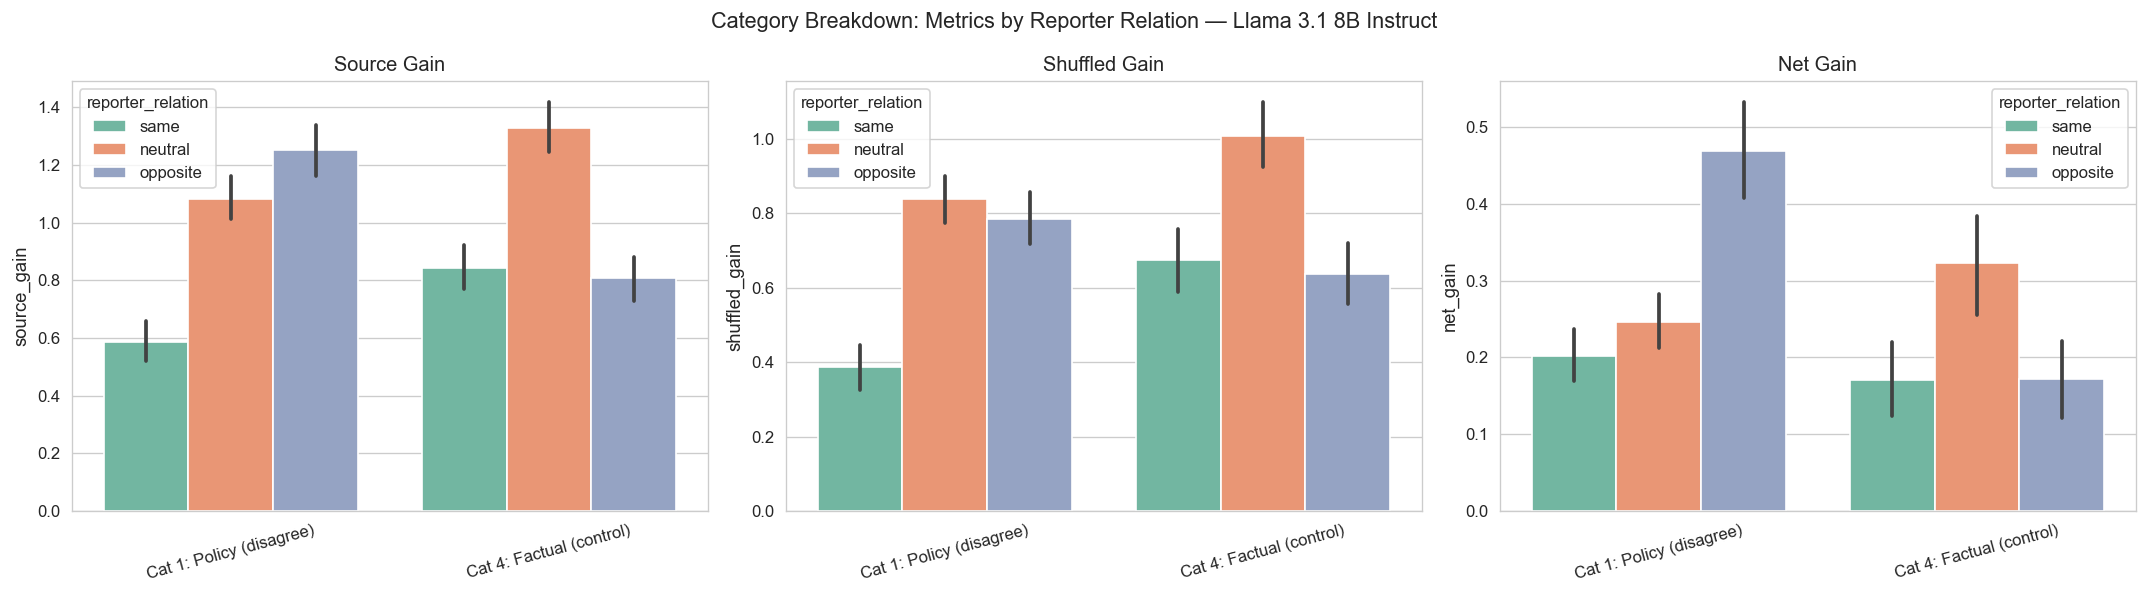

In [14]:
# --- Overview table ---
cat_overview = gdf.groupby('cat_label').agg(
    n_questions=('question_id', 'nunique'),
    source_gain=('source_gain', 'mean'),
    shuffled_gain=('shuffled_gain', 'mean'),
    net_gain=('net_gain', 'mean'),
    pct_positive_net=('net_gain', lambda x: (x > 0).mean()),
    real_accuracy=('real_correct', 'mean'),
    baseline_accuracy=('baseline_correct', 'mean'),
    baseline_agree_rate=('source_direct_answer', lambda x: (gdf.loc[x.index, 'baseline_predicted'] == x).mean()),
).round(3)
display(cat_overview)

# --- Side-by-side bar: source_gain, shuffled_gain, net_gain by category × reporter ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes,
    ['source_gain', 'shuffled_gain', 'net_gain'],
    ['Source Gain', 'Shuffled Gain', 'Net Gain']):
    sns.barplot(data=gdf, x='cat_label', y=metric, hue='reporter_relation',
                hue_order=['same', 'neutral', 'opposite'], ax=ax, ci=95, palette='Set2')
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle(f'Category Breakdown: Metrics by Reporter Relation — {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

## 14. Privileged Access by Category

The privileged access test matters most on **disagreement questions** (cat 1).
On factual questions (cat 4), all personas should agree, so same vs opposite distinction is less meaningful.


Cat 1: Policy (disagree)  (50 questions, 2100 gain records)
        same: source_gain=+0.587  net_gain=+0.201  accuracy(real)=80.7%  accuracy(baseline)=83.0%
     neutral: source_gain=+1.083  net_gain=+0.246  accuracy(real)=41.1%  accuracy(baseline)=41.0%
    opposite: source_gain=+1.252  net_gain=+0.468  accuracy(real)=18.1%  accuracy(baseline)=16.0%

  Disagreement trials: 1120 (53% of total)
          same: flip rate=11.8%  net_gain=+0.225  (119 trials)
       neutral: flip rate=0.2%  net_gain=+0.368  (413 trials)
      opposite: flip rate=5.6%  net_gain=+0.517  (588 trials)

Cat 4: Factual (control)  (35 questions, 1470 gain records)
        same: source_gain=+0.844  net_gain=+0.170  accuracy(real)=71.6%  accuracy(baseline)=60.0%
     neutral: source_gain=+1.329  net_gain=+0.323  accuracy(real)=57.8%  accuracy(baseline)=32.9%
    opposite: source_gain=+0.807  net_gain=+0.171  accuracy(real)=72.7%  accuracy(baseline)=62.9%

  Disagreement trials: 707 (48% of total)
          same: 

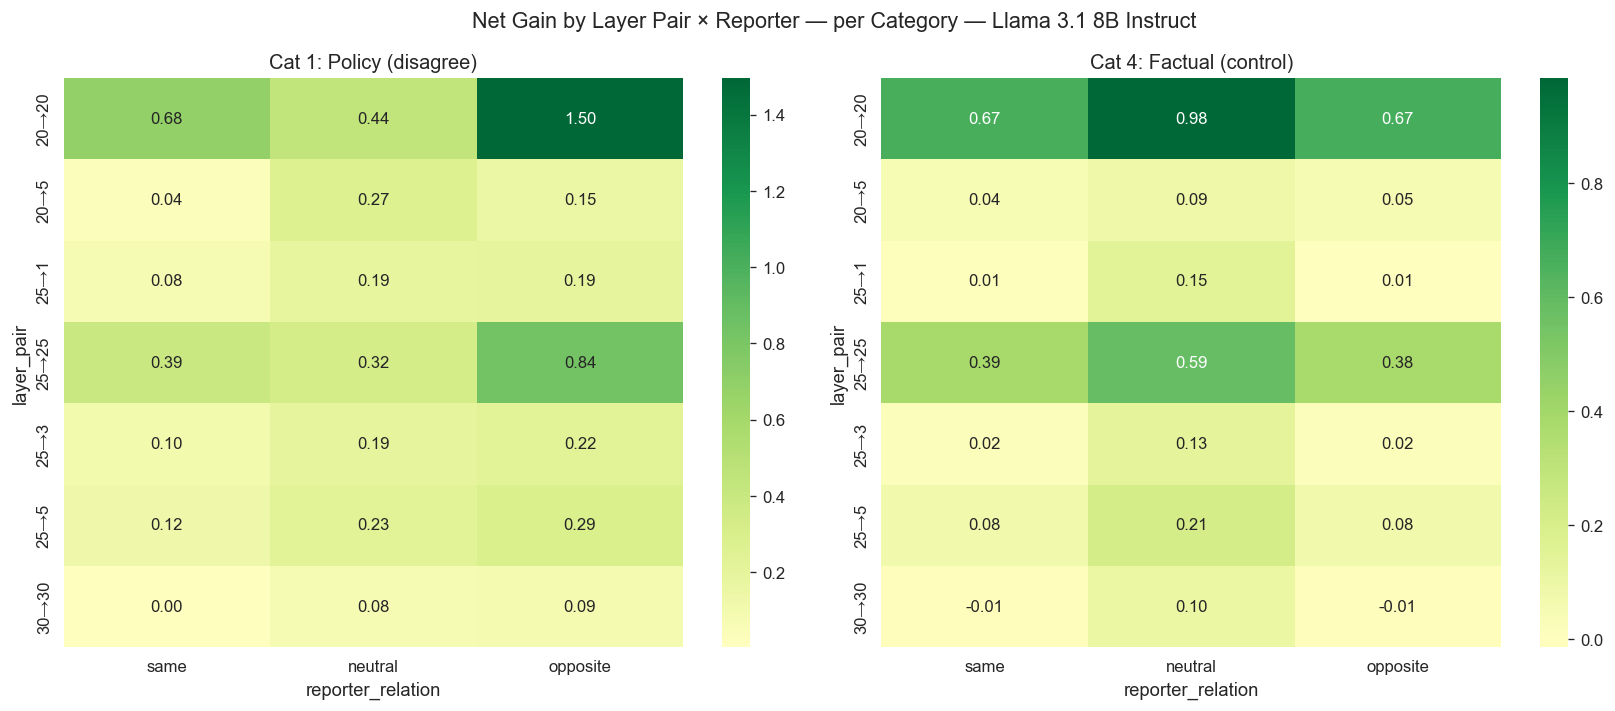

In [15]:
reporter_order = REPORTER_ORDER  # defined in setup

for cat in cats_present:
    cat_label = CAT_LABELS.get(cat, cat)
    sub = gdf[gdf['category'] == cat]
    n_q = sub['question_id'].nunique()

    print(f'\n{"=" * 60}')
    print(f'{cat_label}  ({n_q} questions, {len(sub)} gain records)')
    print(f'{"=" * 60}')

    # Privileged access summary
    for rel in reporter_order:
        rs = sub[sub['reporter_relation'] == rel]
        print(f'  {rel:>10s}: source_gain={rs["source_gain"].mean():+.3f}  '
              f'net_gain={rs["net_gain"].mean():+.3f}  '
              f'accuracy(real)={rs["real_correct"].mean():.1%}  '
              f'accuracy(baseline)={rs["baseline_correct"].mean():.1%}')

    # Disagreement analysis (only meaningful for cat_1)
    sub_disagree = sub[sub['source_direct_answer'] != sub['baseline_predicted']]
    if len(sub_disagree) > 0:
        sub_disagree = sub_disagree.copy()
        sub_disagree['flipped'] = sub_disagree['real_predicted'] == sub_disagree['source_direct_answer']
        print(f'\n  Disagreement trials: {len(sub_disagree)} ({len(sub_disagree)/len(sub):.0%} of total)')
        for rel in reporter_order:
            rs = sub_disagree[sub_disagree['reporter_relation'] == rel]
            if len(rs) > 0:
                print(f'    {rel:>10s}: flip rate={rs["flipped"].mean():.1%}  '
                      f'net_gain={rs["net_gain"].mean():+.3f}  ({len(rs)} trials)')

# --- Heatmaps per category ---
fig, axes = plt.subplots(1, len(cats_present), figsize=(7 * len(cats_present), 6))
if len(cats_present) == 1:
    axes = [axes]
for ax, cat in zip(axes, cats_present):
    sub = gdf[gdf['category'] == cat]
    pivot = sub.pivot_table(values='net_gain', index='layer_pair', columns='reporter_relation',
                            aggfunc='mean')[reporter_order]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
    ax.set_title(f'{CAT_LABELS.get(cat, cat)}')

fig.suptitle(f'Net Gain by Layer Pair × Reporter — per Category — {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

## 15. Cat 1 vs Cat 4: Direct Comparison

Side-by-side view of the key metrics. If patchscope is working:
- **Cat 1 (disagree)**: large net_gain on opposite reporters = the injection overcomes the reporter's opposing prior
- **Cat 4 (factual)**: small net_gain everywhere = both source and reporter already agree, injection adds little
- **Flip rate on cat 1 disagree trials**: how often does the injection actually change the reporter's predicted answer?

/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3934451757.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=comp, x='reporter_relation', y=metric, hue='cat_label',
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3934451757.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=comp, x='reporter_relation', y=metric, hue='cat_label',
/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_31824/3934451757.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=comp, x='reporter_relation', y=metric, hue='cat_label',


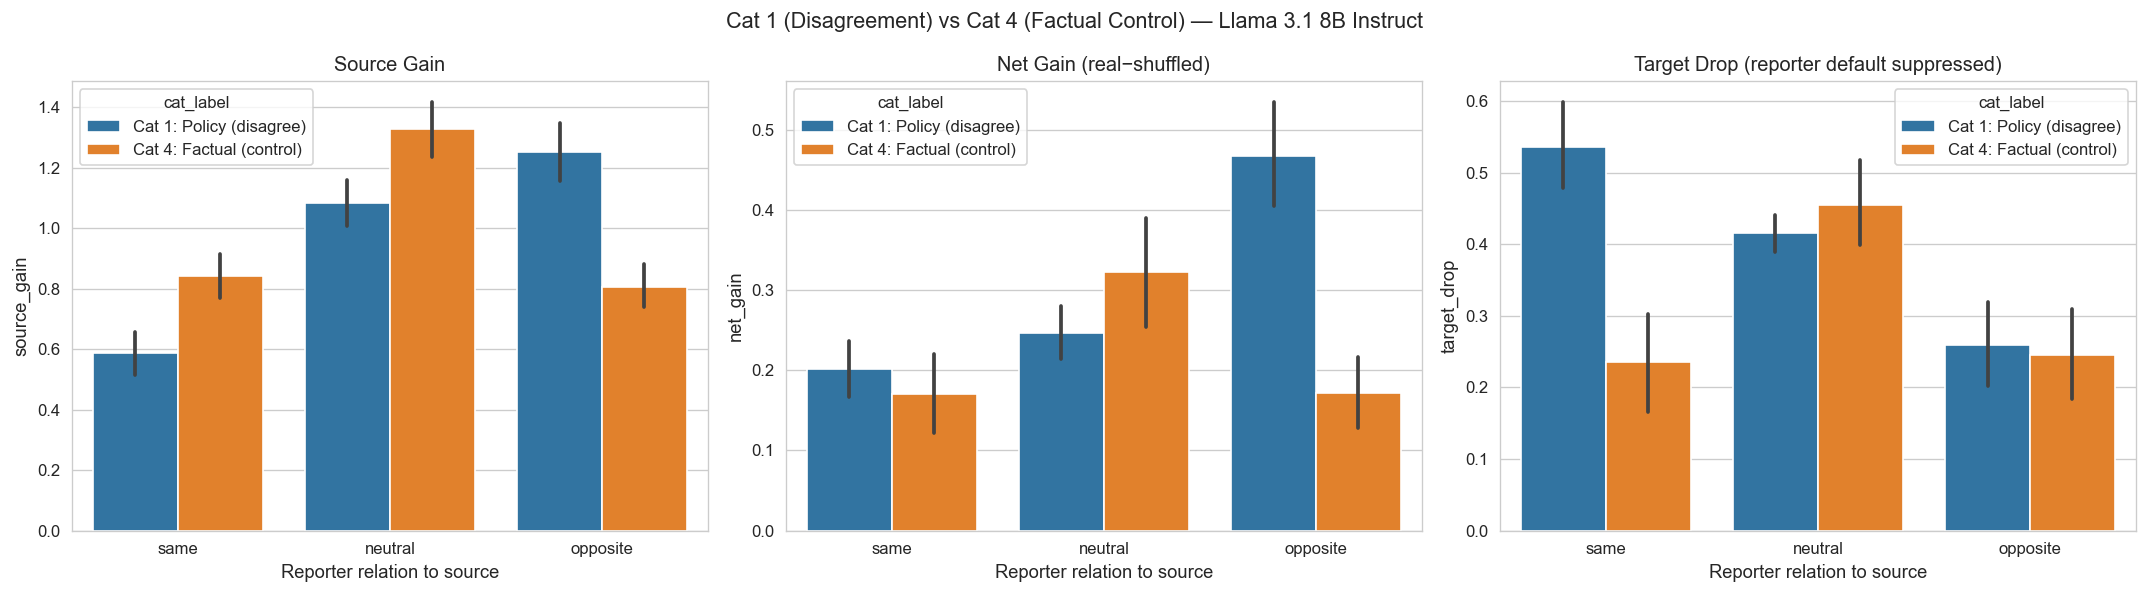

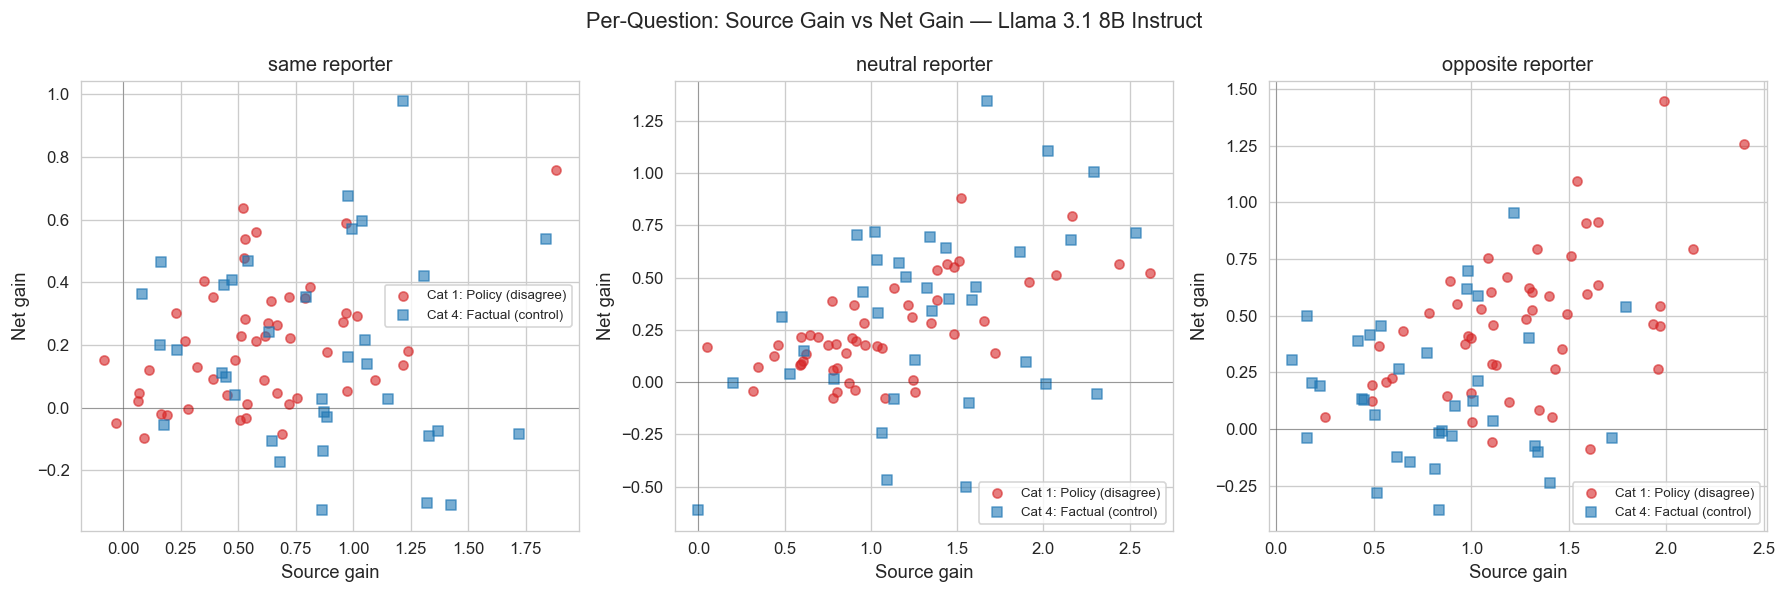

In [16]:
# Direct cat_1 vs cat_4 comparison
cats_compare = [c for c in ['cat_1', 'cat_4'] if c in gdf['category'].values]
if len(cats_compare) == 2:
    comp = gdf[gdf['category'].isin(cats_compare)].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric, title in zip(axes,
        ['source_gain', 'net_gain', 'target_drop'],
        ['Source Gain', 'Net Gain (real−shuffled)', 'Target Drop (reporter default suppressed)']):
        sns.barplot(data=comp, x='reporter_relation', y=metric, hue='cat_label',
                    order=['same', 'neutral', 'opposite'], ax=ax, ci=95)
        ax.set_title(title)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_xlabel('Reporter relation to source')

    fig.suptitle(f'Cat 1 (Disagreement) vs Cat 4 (Factual Control) — {MODEL}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Scatter: per-question average net_gain, colored by category
    q_cat = gdf.groupby(['question_id', 'category', 'cat_label', 'reporter_relation']).agg(
        net_gain=('net_gain', 'mean'),
        source_gain=('source_gain', 'mean'),
    ).reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, rel in zip(axes, ['same', 'neutral', 'opposite']):
        sub = q_cat[q_cat['reporter_relation'] == rel]
        for cat, color, marker in zip(cats_compare, ['tab:red', 'tab:blue'], ['o', 's']):
            csub = sub[sub['category'] == cat]
            ax.scatter(csub['source_gain'], csub['net_gain'], alpha=0.6, s=30,
                       c=color, marker=marker, label=CAT_LABELS[cat])
        ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
        ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)
        ax.set_xlabel('Source gain')
        ax.set_ylabel('Net gain')
        ax.set_title(f'{rel} reporter')
        ax.legend(fontsize=8)

    fig.suptitle(f'Per-Question: Source Gain vs Net Gain — {MODEL}', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print(f'Only found categories: {cats_compare}. Need both cat_1 and cat_4 for comparison.')

## 16. Persona Agreement Patterns

### A. Cross-persona agreement by category
For each question, what answer did each persona choose (as source)? How often do conservative, progressive, and neutral agree or disagree?

### B. Self-consistency across prompt formats
The same persona answers the question twice in different formats:
- **Source pass**: full chat conversation (used to extract activations)
- **Reporter baseline**: patchscopes interpretation template with no injection

How often does the same persona give the same answer in both formats? Low self-consistency means the persona's answer is prompt-dependent, not a stable internal preference.

Cross-persona agreement rates:
  Conservative ↔ Progressive:          50.6%
  Conservative ↔ Neutral (reporter baseline): 36.5%
  Progressive  ↔ Neutral (reporter baseline): 38.8%
  All three agree:                     21.2%


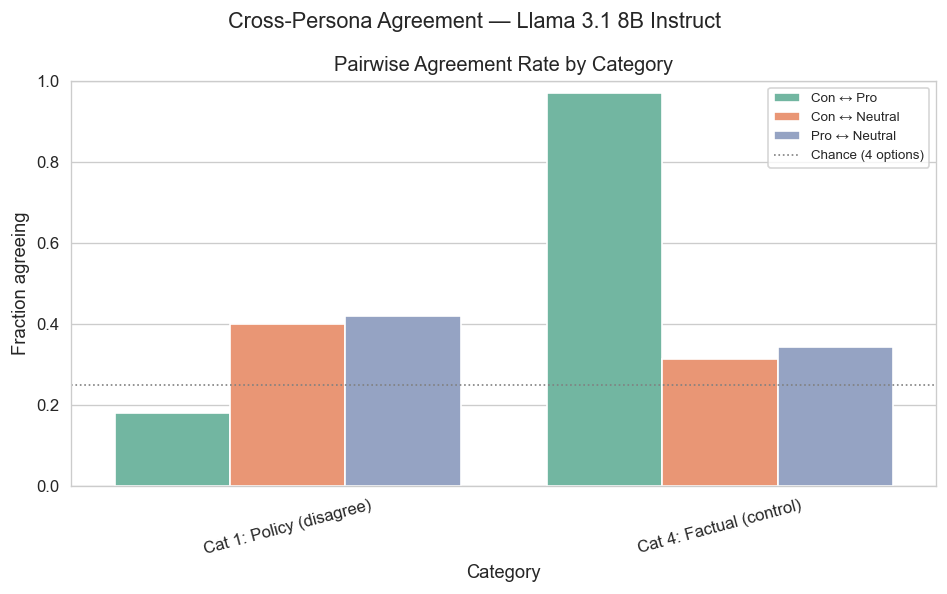

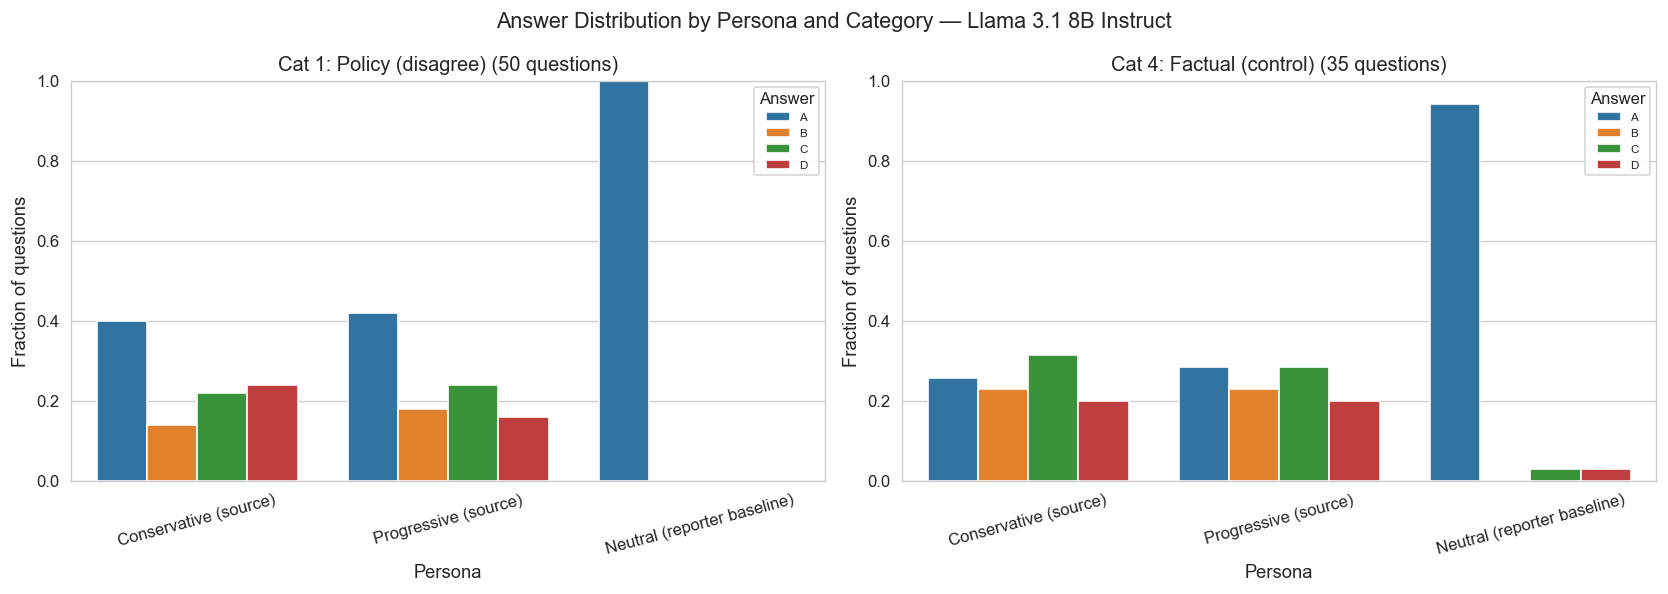

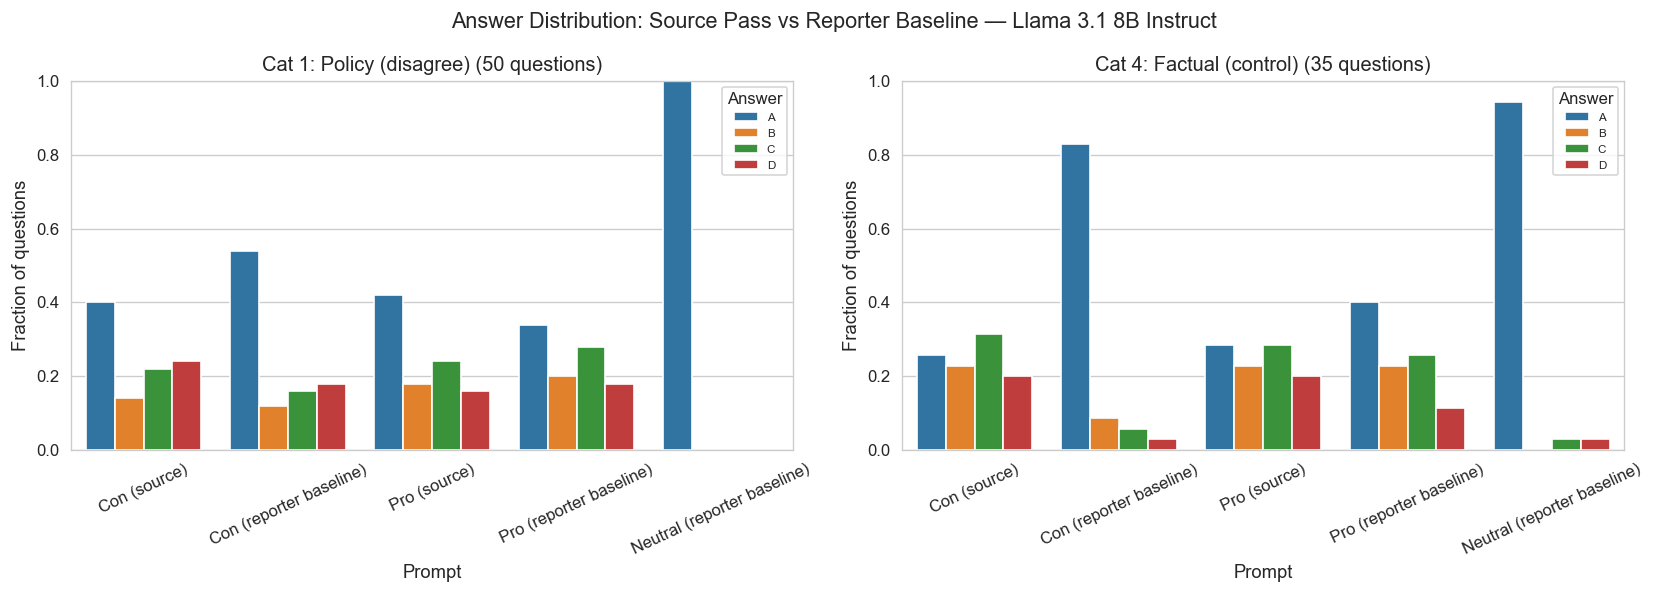


Per-category agreement breakdown:

  Cat 1: Policy (disagree) (50 questions):
    Con ↔ Pro agree: 18.0%
    Con ↔ Neutral:   40.0%
    Pro ↔ Neutral:   42.0%
    All agree:       14.0%

  Cat 4: Factual (control) (35 questions):
    Con ↔ Pro agree: 97.1%
    Con ↔ Neutral:   31.4%
    Pro ↔ Neutral:   34.3%
    All agree:       31.4%


In [17]:
# ============================================================
# A. Cross-persona agreement by category
# ============================================================
ae = df[df['template_name'] == 'answer_extraction'].copy()
source_answers = ae.groupby(['question_id', 'source_persona'])['source_direct_answer'].first().unstack()
source_answers = source_answers.merge(df[['question_id', 'category']].drop_duplicates(), on='question_id')

# Neutral only appears as reporter — use baseline predicted
baseline = ae[(ae['condition'] == 'text_only_baseline') & (ae['reporter_persona'] == 'neutral_reporter')]
neutral_answers = baseline.groupby('question_id')['predicted'].first().rename('neutral_reporter')
source_answers = source_answers.merge(neutral_answers, on='question_id', how='left')
source_answers['cat_label'] = source_answers['category'].map(CAT_LABELS).fillna(source_answers['category'])

# Also get reporter baseline answers for con/pro (same persona, no injection)
for persona in ['persona_conservative', 'persona_progressive']:
    bl = ae[(ae['condition'] == 'text_only_baseline') & (ae['reporter_persona'] == persona)]
    bl_answers = bl.groupby('question_id')['predicted'].first().rename(f'{persona}_eval')
    source_answers = source_answers.merge(bl_answers, on='question_id', how='left')

# Agreement patterns
source_answers['con_pro_agree'] = source_answers['persona_conservative'] == source_answers['persona_progressive']
source_answers['con_neu_agree'] = source_answers['persona_conservative'] == source_answers['neutral_reporter']
source_answers['pro_neu_agree'] = source_answers['persona_progressive'] == source_answers['neutral_reporter']
source_answers['all_agree'] = source_answers['con_pro_agree'] & source_answers['con_neu_agree']

print('Cross-persona agreement rates:')
print(f'  Conservative ↔ Progressive:          {source_answers["con_pro_agree"].mean():.1%}')
print(f'  Conservative ↔ Neutral (reporter baseline): {source_answers["con_neu_agree"].mean():.1%}')
print(f'  Progressive  ↔ Neutral (reporter baseline): {source_answers["pro_neu_agree"].mean():.1%}')
print(f'  All three agree:                     {source_answers["all_agree"].mean():.1%}')

# --- Plot 1: pairwise agreement rates by category ---
fig, ax = plt.subplots(figsize=(8, 5))
pairs = [('con_pro_agree', 'Con ↔ Pro'), ('con_neu_agree', 'Con ↔ Neutral'), ('pro_neu_agree', 'Pro ↔ Neutral')]
pair_data = []
for cat in sorted(source_answers['category'].unique()):
    sub = source_answers[source_answers['category'] == cat]
    cl = CAT_LABELS.get(cat, cat)
    for col, label in pairs:
        pair_data.append({'Category': cl, 'Pair': label, 'Agreement': sub[col].mean()})
pair_df = pd.DataFrame(pair_data)
sns.barplot(data=pair_df, x='Category', y='Agreement', hue='Pair', ax=ax, palette='Set2')
ax.set_title('Pairwise Agreement Rate by Category')
ax.set_ylabel('Fraction agreeing')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=15)
ax.axhline(0.25, color='gray', linestyle=':', linewidth=1, label='Chance (4 options)')
ax.legend(fontsize=8)
plt.suptitle(f'Cross-Persona Agreement — {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

# --- Plot 2: answer distribution by persona × category ---
persona_cols = [
    ('persona_conservative', 'Conservative (source)'),
    ('persona_progressive', 'Progressive (source)'),
    ('neutral_reporter', 'Neutral (reporter baseline)'),
]
cats_sorted = sorted(source_answers['category'].unique())

fig, axes = plt.subplots(1, len(cats_sorted), figsize=(7 * len(cats_sorted), 5))
if len(cats_sorted) == 1:
    axes = [axes]
for ax, cat in zip(axes, cats_sorted):
    sub = source_answers[source_answers['category'] == cat]
    cl = CAT_LABELS.get(cat, cat)
    answer_dist = []
    for p, label in persona_cols:
        counts = sub[p].value_counts(normalize=True)
        for ans, frac in counts.items():
            answer_dist.append({'Persona': label, 'Answer': ans, 'Fraction': frac})
    ans_df = pd.DataFrame(answer_dist)
    sns.barplot(data=ans_df, x='Persona', y='Fraction', hue='Answer',
                hue_order=['A', 'B', 'C', 'D'], ax=ax, palette='tab10')
    ax.set_title(f'{cl} ({len(sub)} questions)')
    ax.set_ylabel('Fraction of questions')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=7, title='Answer')
fig.suptitle(f'Answer Distribution by Persona and Category — {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

# --- Plot 3: answer distribution by prompt type (source vs reporter baseline) ---
# Compare: same persona, source pass vs reporter baseline, per category
prompt_cols = [
    ('persona_conservative', 'Con (source)'),
    ('persona_conservative_eval', 'Con (reporter baseline)'),
    ('persona_progressive', 'Pro (source)'),
    ('persona_progressive_eval', 'Pro (reporter baseline)'),
    ('neutral_reporter', 'Neutral (reporter baseline)'),
]

fig, axes = plt.subplots(1, len(cats_sorted), figsize=(7 * len(cats_sorted), 5))
if len(cats_sorted) == 1:
    axes = [axes]
for ax, cat in zip(axes, cats_sorted):
    sub = source_answers[source_answers['category'] == cat]
    cl = CAT_LABELS.get(cat, cat)
    prompt_dist = []
    for col, label in prompt_cols:
        if col not in sub.columns:
            continue
        counts = sub[col].value_counts(normalize=True)
        for ans, frac in counts.items():
            prompt_dist.append({'Prompt': label, 'Answer': ans, 'Fraction': frac})
    pdf = pd.DataFrame(prompt_dist)
    sns.barplot(data=pdf, x='Prompt', y='Fraction', hue='Answer',
                hue_order=['A', 'B', 'C', 'D'], ax=ax, palette='tab10')
    ax.set_title(f'{cl} ({len(sub)} questions)')
    ax.set_ylabel('Fraction of questions')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=7, title='Answer')
fig.suptitle(f'Answer Distribution: Source Pass vs Reporter Baseline — {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

# --- Per-category breakdown ---
print('\nPer-category agreement breakdown:')
for cat in sorted(source_answers['category'].unique()):
    sub = source_answers[source_answers['category'] == cat]
    cl = CAT_LABELS.get(cat, cat)
    print(f'\n  {cl} ({len(sub)} questions):')
    print(f'    Con ↔ Pro agree: {sub["con_pro_agree"].mean():.1%}')
    print(f'    Con ↔ Neutral:   {sub["con_neu_agree"].mean():.1%}')
    print(f'    Pro ↔ Neutral:   {sub["pro_neu_agree"].mean():.1%}')
    print(f'    All agree:       {sub["all_agree"].mean():.1%}')

Self-consistency: same persona, source pass vs reporter baseline
Overall: 73.5% consistent
  Conservative: 62.4% (85 questions)
  Progressive: 84.7% (85 questions)


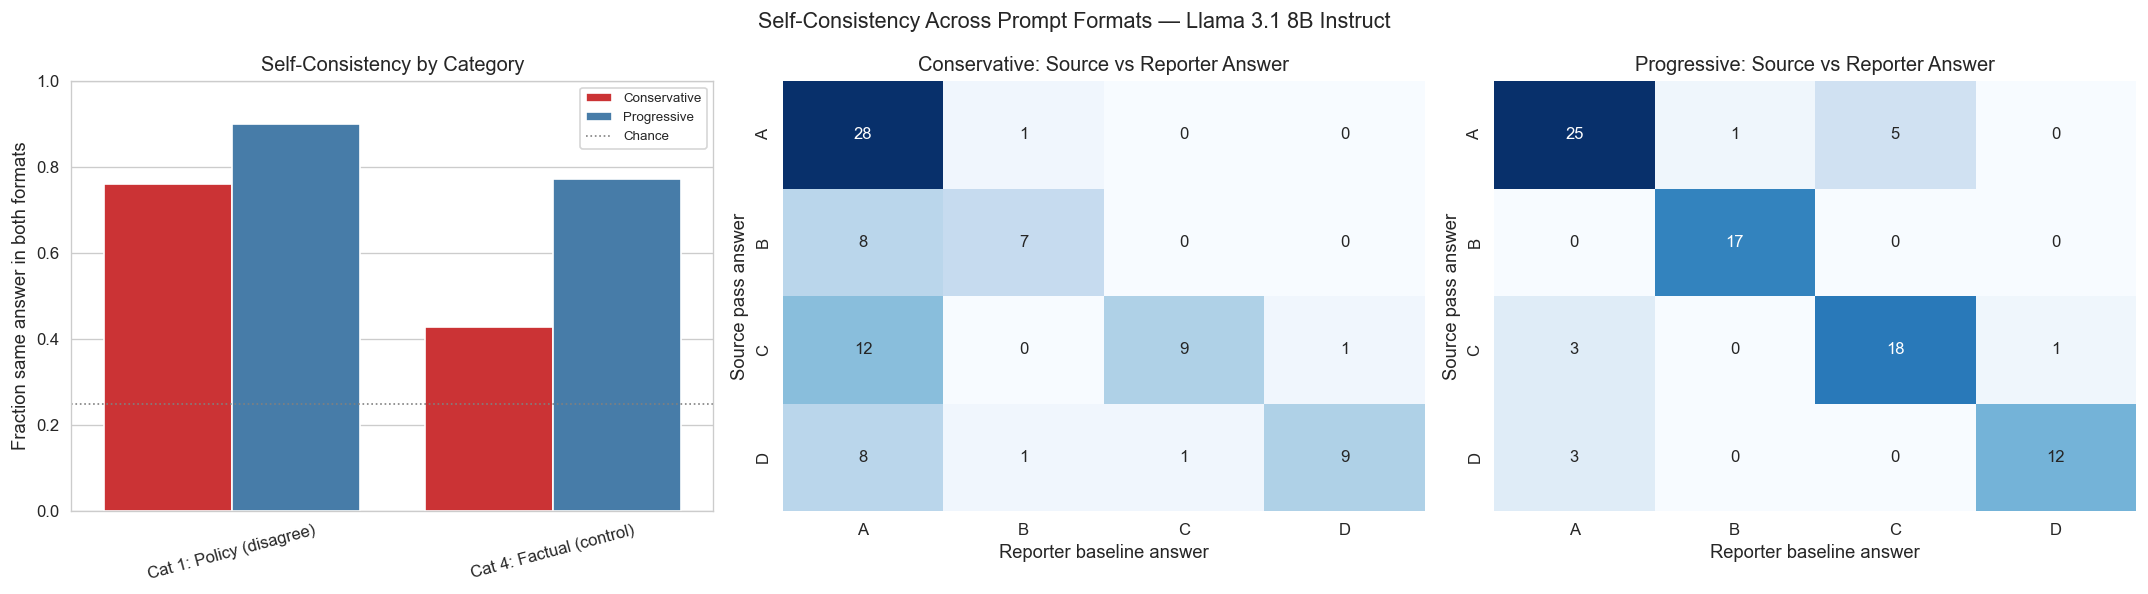


Inconsistent questions: 36 / 85

Per-category self-consistency:
  Cat 1: Policy (disagree): 83.0% (100 persona-question pairs)
  Cat 4: Factual (control): 60.0% (70 persona-question pairs)


In [18]:
# ============================================================
# B. Self-consistency: same persona, source pass vs reporter baseline
# ============================================================
# source_direct_answer = what persona chose in the source (chat) pass
# baseline predicted = what the SAME persona chose in the reporter (patchscopes template) pass
#
# For each (question, persona), compare source_direct_answer with baseline predicted
# when reporter_persona == source_persona and condition == text_only_baseline

ae_baseline = ae[ae['condition'] == 'text_only_baseline'].copy()
# Only keep rows where reporter == source (same persona evaluating itself)
self_eval = ae_baseline[ae_baseline['reporter_persona'] == ae_baseline['source_persona']].copy()
# Deduplicate: one row per (question, persona) — take first layer pair
self_eval = self_eval.groupby(['question_id', 'source_persona']).first().reset_index()
self_eval['self_consistent'] = self_eval['source_direct_answer'] == self_eval['predicted']
self_eval['cat_label'] = self_eval['category'].map(CAT_LABELS).fillna(self_eval['category'])

print('Self-consistency: same persona, source pass vs reporter baseline')
print('=' * 60)
print(f'Overall: {self_eval["self_consistent"].mean():.1%} consistent')

for p in ['persona_conservative', 'persona_progressive']:
    sub = self_eval[self_eval['source_persona'] == p]
    print(f'  {PERSONA_LABELS[p]}: {sub["self_consistent"].mean():.1%} ({len(sub)} questions)')

# --- Visualize ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Self-consistency by persona × category
consist_data = self_eval.groupby(['cat_label', 'source_persona'])['self_consistent'].mean().reset_index()
consist_data['Persona'] = consist_data['source_persona'].map(PERSONA_LABELS)
sns.barplot(data=consist_data, x='cat_label', y='self_consistent', hue='Persona', ax=axes[0], palette='Set1')
axes[0].set_title('Self-Consistency by Category')
axes[0].set_ylabel('Fraction same answer in both formats')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.25, color='gray', linestyle=':', linewidth=1, label='Chance')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=8)

# 2. Confusion matrix: source answer vs reporter baseline answer (conservative)
for ax, persona, title in zip(axes[1:],
    ['persona_conservative', 'persona_progressive'],
    ['Conservative', 'Progressive']):
    sub = self_eval[self_eval['source_persona'] == persona]
    options = ['A', 'B', 'C', 'D']
    confusion = pd.crosstab(
        sub['source_direct_answer'].astype(str),
        sub['predicted'].astype(str),
        dropna=False
    ).reindex(index=options, columns=options, fill_value=0)
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_xlabel('Reporter baseline answer')
    ax.set_ylabel('Source pass answer')
    ax.set_title(f'{title}: Source vs Reporter Answer')

fig.suptitle(f'Self-Consistency Across Prompt Formats — {MODEL}', fontsize=13)
plt.tight_layout()
plt.show()

# --- Which questions are inconsistent? ---
inconsistent = self_eval[~self_eval['self_consistent']]
print(f'\nInconsistent questions: {inconsistent["question_id"].nunique()} / {self_eval["question_id"].nunique()}')
print(f'\nPer-category self-consistency:')
for cat in sorted(self_eval['category'].unique()):
    sub = self_eval[self_eval['category'] == cat]
    cl = CAT_LABELS.get(cat, cat)
    print(f'  {cl}: {sub["self_consistent"].mean():.1%} ({len(sub)} persona-question pairs)')